# ME5413 Homework 3: Planning

## Task 0: Load the Map

In [1]:
import numpy as np
import imageio
import matplotlib.pyplot as plt
%matplotlib inline

/tmp/ipykernel_1357814/187924686.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  floor_plan = imageio.imread('./map/vivocity.png')
/tmp/ipykernel_1357814/187924686.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  grid_map_img = imageio.imread('./map/vivocity_freespace.png')


Size of the map: (1000, 1000)
Occupied Cells: 823039
Free Cells: 176961


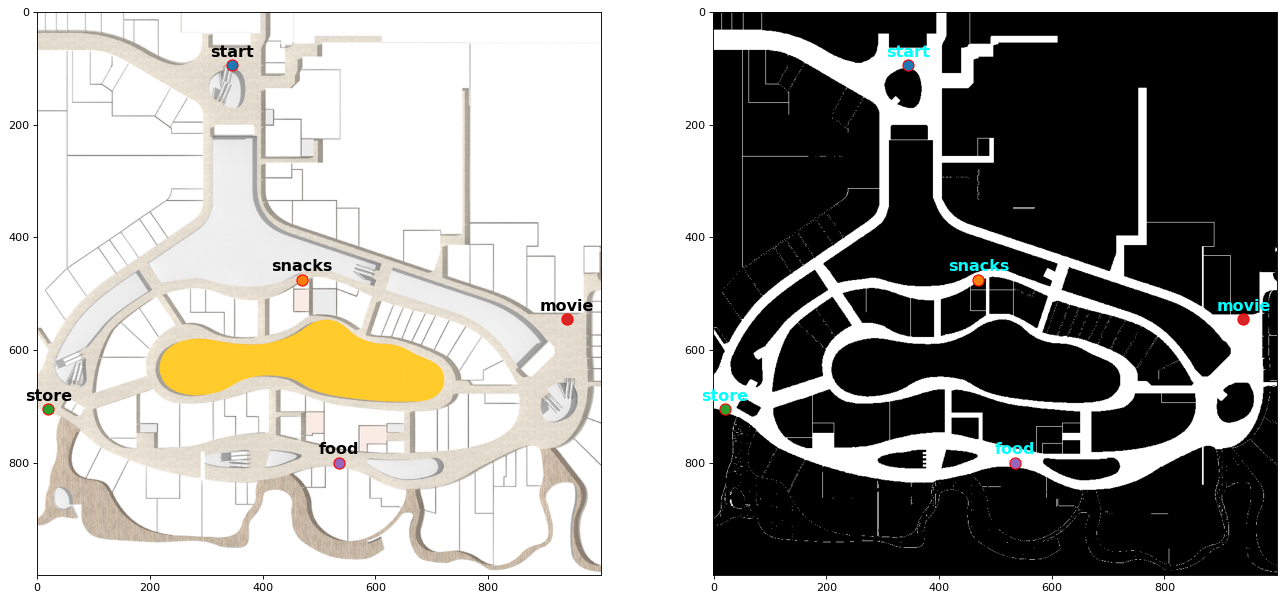

Cell start is free: True
Cell snacks is free: True
Cell store is free: True
Cell movie is free: True
Cell food is free: True


In [2]:
# Load the map
floor_plan = imageio.imread('./map/vivocity.png')
grid_map_img = imageio.imread('./map/vivocity_freespace.png')
grid_map = grid_map_img.transpose()
print("Size of the map:", grid_map.shape)
print("Occupied Cells:", np.count_nonzero(grid_map == 0))
print("Free Cells:", np.count_nonzero(grid_map == 255))

# Map resolution (Constant)
MAP_RES = 0.2 # each cell represents a 0.2m x 0.2m square in reality

# Locations on the map
locations = {'start':  [345, 95],    # Start from the level 2 Escalator
             'snacks': [470, 475],   # Garrett Popcorn
             'store':  [20, 705],    # DJI Store
             'movie':  [940, 545],   # Golden Village
             'food':   [535, 800],   # PUTIEN
            }

# A helper function to mark the locations on the map
def plot_locations(locations: dict, color: 'str'='black'):
    for key, value in locations.items():
        plt.plot(locations[key][0], locations[key][1], marker="o", markersize=10, markeredgecolor="red")
        plt.text(locations[key][0], locations[key][1]-15, s=key, fontsize='x-large', fontweight='bold', c=color, ha='center')
    return

# Plot the locaitons on the map 
plt.figure(figsize=(20, 10), dpi=80)
plt.subplot(1,2,1)
plt.imshow(floor_plan)
plot_locations(locations)
plt.subplot(1,2,2)
plt.imshow(grid_map_img, cmap='gray')
plot_locations(locations, color='cyan')
plt.show()

# Check if the designated locations are free
for key, value in locations.items():
    print(f"Cell {key} is free: {grid_map[value[0], value[1]] == 255}")

## Task 1

In [3]:
import datetime
from math import sqrt

class Node():
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.g = 0 # cost from start
        self.h = 0 # cost to end
        self.f = 0
        self.parent = None

    def calculate_h(self, end_node, h_MODE):
        self.h = "NaN"
        if h_MODE == "Dij":
            self.h = 0
        elif h_MODE == "Manhattan":
            self.h = 0.2*(abs(end_node.x - self.x) + abs(end_node.y - self.y))
        elif h_MODE == "Chebyshev":
            self.h = 0.2*max(abs(end_node.x - self.x),abs(end_node.y - self.y))
        elif h_MODE == "Euclidean":
            self.h = 0.2* sqrt((end_node.x - self.x)**2 + (end_node.y - self.y)**2 )
    
    def calculate_adj_cost(self):
        dx = abs(self.parent.x - self.x) if self.parent !=None else 0
        dy = abs(self.parent.y - self.y) if self.parent !=None else 0
        cost = 0.2*(dx+dy) + (0.282-2*0.2)*min(dx,dy)
        return round(cost,3)

    def set_parent(self, parent_node, g_MODE):
        self.parent = parent_node
        self.g = "NaN"
        if g_MODE == "GBFS":
            self.g = 0
        elif g_MODE == "Standard":
            self.g = parent_node.g + 1
        self.f = self.g + self.h

        


def print_nlst(lst):
    print([ (item.x, item.y) for item in lst])

def print_node(node, name):
    print(f"{name}:{(node.x, node.y)}")


def astar_find_path(map, ngb_MODE, h_MODE, g_MODE, start_node, end_node):
    open_list = []
    closed_set = set()
    open_list.append(start_node)


    while len(open_list) > 0:
        # print_nlst(open_list)
        start_time = datetime.datetime.now()

        current_node = min(open_list, key=lambda x: x.f)
        open_list.remove(current_node)
        closed_set.add((current_node.x,current_node.y) )
        # print_node(current_node, "curr")
        # print(map[current_node.x, current_node.y])

        if current_node.x == end_node.x and current_node.y == end_node.y:
            path = []
            cost = 0
            while current_node is not None:
                path.append((current_node.x, current_node.y))
                
                cost+= current_node.calculate_adj_cost()

                current_node = current_node.parent
                
            end_time = datetime.datetime.now()
            time_difference = (end_time - start_time).total_seconds()
            return path[::-1], f"{cost:.3f}m", list(closed_set), str(time_difference) +"s"
        
        ngb_lst = "NaN"
        if ngb_MODE == "8-ngb":
            ngb_lst = [(1, 0), (-1, 0), (0, 1), (0, -1), (-1,1), (1,1), (-1,-1), (1,-1)]
        elif ngb_MODE == "4-ngb":
            ngb_lst =[(1, 0), (-1, 0), (0, 1), (0, -1)]

        for x_offset, y_offset in ngb_lst:
            neighbor_x = current_node.x + x_offset
            neighbor_y = current_node.y + y_offset


            if neighbor_x < 0 or neighbor_x >= map.shape[0] or neighbor_y < 0 or neighbor_y >= map.shape[1]:
                continue
            
            if map[neighbor_x][neighbor_y] == 0:
                continue


            if (neighbor_x, neighbor_y) in closed_set:
                continue
            
            # Check if neighbor is in open_list
            existing_node = next((n for n in open_list if n.x == neighbor_x and n.y == neighbor_y), None)

            if existing_node is None:
                # Create a new node if not in open_list
                neighbor_node = Node(neighbor_x, neighbor_y)
                neighbor_node.calculate_h(end_node, h_MODE)
                neighbor_node.set_parent(current_node, g_MODE)
                open_list.append(neighbor_node)
            else:
                # If already in open_list, check if this path is better
                new_g = current_node.g + 1
                if new_g < existing_node.g:
                    existing_node.set_parent(current_node)


    return None

In [4]:
def draw_path(path):

    # Extract x and y coordinates
    x_values, y_values = zip(*path)

    # Plot the path
    plt.plot(x_values, y_values, linestyle='-', linewidth=2,color='b', label="Path")
    arrow_start = path[-2]  # 倒数第二个点
    arrow_end = path[-1]  # 终点

    # dx = arrow_end[0] - arrow_start[0]  # 计算箭头方向
    # dy = arrow_end[1] - arrow_start[1]

    plt.annotate('', xy=path[-1], xytext=path[-2],
             arrowprops=dict(arrowstyle='->', color='b', 
                            lw=2, shrinkA=0, shrinkB=0,
                            mutation_scale=10))


def plot_start_end(locations, start_name, end_name):
    for key, value in locations.items():
        plt.plot(locations[key][0], locations[key][1],
                  marker="o", markersize=10, markerfacecolor= "grey", markeredgecolor="red")

    plt.plot(locations[start_name][0], locations[start_name][1], 
             marker="o", markersize=10, markerfacecolor= "green",markeredgecolor="cyan")
    plt.text(locations[start_name][0], locations[start_name][1]-15, 
             s=f"[start]\n{start_name}", fontsize='x-large', fontweight='bold', c="cyan", ha='center')
    
    plt.plot(locations[end_name][0], locations[end_name][1], 
             marker="o", markersize=10, markerfacecolor= "yellow",markeredgecolor="cyan")
    plt.text(locations[end_name][0], locations[end_name][1]-15, 
             s=f"[end]\n{end_name}", fontsize='x-large', fontweight='bold', c="cyan", ha='center')
    

### Single Test and Display

from start to store
length of path: 652
length of all_visited_cells: 72973
distance cost: 162.180m
time cost: 0.000559s


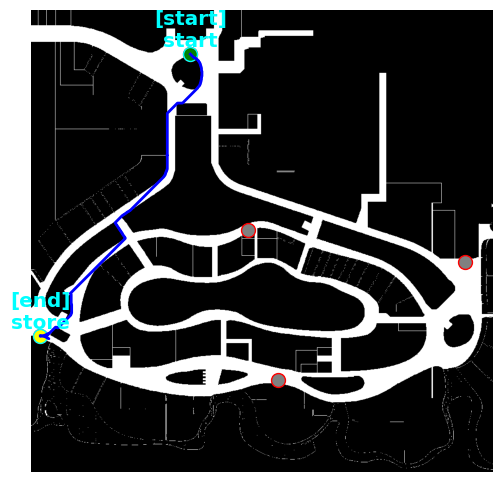

In [5]:
# locations = {'start':  [345, 95],    # Start from the level 2 Escalator
#             'snacks': [470, 475],   # Garrett Popcorn
#             'store':  [20, 705],    # DJI Store
#             'movie':  [940, 545],   # Golden Village
#             'food':   [535, 800],   # PUTIEN
#             }


ngb_MODE = "8-ngb" # you can select "4-ngb" or "8-ngb"
h_MODE = "Manhattan" # you can select "Manhattan", "Euclidean" or "Chebyshev"
g_MODE = "Standard" # you can select "Standard" or "GBFS"

start_n = "start"
end_n = "store"

start_p = locations[start_n]
end_p = locations[end_n]

start_node = Node(start_p[0], start_p[1])
end_node = Node(end_p[0], end_p[1])

path, dis_cost, all_visited_cells, time_cost = astar_find_path(grid_map, ngb_MODE, h_MODE,g_MODE, start_node, end_node)
print(f"from {start_n} to {end_n}")
print(f"length of path: {len(path)}")
print(f"length of all_visited_cells: {len(all_visited_cells)}")
print(f"distance cost: {dis_cost}")
print(f"time cost: {time_cost}")

# 显示图像
plt.figure(figsize=(8, 6), dpi=100)
plt.imshow(grid_map_img, cmap='gray')

plot_start_end(locations, start_n, end_n)
draw_path(path)


plt.axis("off")  # 去除坐标轴
plt.show()

### Iterative Experiment

In [5]:
from itertools import permutations


import os
loca_lst = ['start','snacks', 'store','movie','food' ]
exp_pairs = list(permutations(loca_lst, 2))

ngb_MODE = "8-ngb" # you can select "4-ngb" or "8-ngb"
h_MODE = "Chebyshev" # you can select "Manhattan", "Euclidean" or "Chebyshev" or "Dij"
g_MODE = "Standard" # you can select "Standard" or "GBFS"

save_path = f'{ngb_MODE}_{h_MODE}_res.txt' if g_MODE !="GBFS" else f'{ngb_MODE}_{g_MODE}_res.txt'
if os.path.exists(save_path):
    os.remove(save_path)

print(f"h_MODE: {h_MODE}, g_MODE: {g_MODE}")

for pair in exp_pairs:
    start_n = pair[0]
    end_n = pair[1]
    start_p = locations[start_n]
    end_p = locations[end_n]

    start_node = Node(start_p[0], start_p[1])
    end_node = Node(end_p[0], end_p[1])


    path, dis_cost, all_visited_cells, time_cost = astar_find_path(grid_map, ngb_MODE, h_MODE,g_MODE, start_node, end_node)
    

    with open(save_path, "a+") as f1:
        print(f"planning {start_n} -> {end_n}")
        f1.write(f"{start_n}->{end_n}, distance cost={dis_cost}, time cost={time_cost}\n")
        f1.write(f"\tpath cells={len(path)}, all visited cells={len(all_visited_cells)}\n")
        f1.write("\n")
print('Done.')

h_MODE: Chebyshev, g_MODE: Standard
planning start -> snacks
planning start -> store
planning start -> movie
planning start -> food
planning snacks -> start
planning snacks -> store
planning snacks -> movie
planning snacks -> food
planning store -> start
planning store -> snacks
planning store -> movie
planning store -> food
planning movie -> start
planning movie -> snacks
planning movie -> store
planning movie -> food
planning food -> start
planning food -> snacks
planning food -> store
planning food -> movie
Done.


## Task 2

In [11]:
# Dijkstra Algorithm
import heapq
from itertools import permutations

def dijkstra(graph, start):
    n = len(graph)
    dist = [float('inf')] * n
    dist[start] = 0
    pq = [(0, start)]
    
    while pq:
        current_dist, u = heapq.heappop(pq)
        if current_dist > dist[u]:
            continue
        for v in range(n):
            if graph[u][v] > 0:  # 有效边
                new_dist = dist[u] + graph[u][v]
                if new_dist < dist[v]:
                    dist[v] = new_dist
                    heapq.heappush(pq, (new_dist, v))
    
    return dist

def compute_all_pairs_shortest_paths(graph):
    n = len(graph)
    dist_matrix = []
    for i in range(n):
        dist_matrix.append(dijkstra(graph, i))
    return dist_matrix

def tsp_dijkstra(graph):
    dist = compute_all_pairs_shortest_paths(graph)
    n = len(graph)
    all_points = set(range(1, n))
    min_cost = float('inf')
    best_path = []
    
    for perm in permutations(all_points):
        cost = dist[0][perm[0]] + sum(dist[perm[i]][perm[i+1]] for i in range(len(perm)-1)) + dist[perm[-1]][0]
        if cost < min_cost:
            min_cost = cost
            best_path = [0] + list(perm) + [0]
    
    return min_cost, best_path

In [12]:
# Floyd Algorithm
from itertools import permutations
import numpy as np

def floyd_warshall(graph):
    num_vertices = len(graph)
    dist = np.array(graph, dtype=float)
    
    for k in range(num_vertices):
        for i in range(num_vertices):
            for j in range(num_vertices):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]
    
    return dist

def tsp_floyd(graph):
    dist = floyd_warshall(graph)
    n = len(graph)
    all_points = set(range(1, n))
    min_cost = float('inf')
    best_path = []
    
    for perm in permutations(all_points):
        cost = dist[0][perm[0]] + sum(dist[perm[i]][perm[i+1]] for i in range(len(perm)-1)) + dist[perm[-1]][0]
        if cost < min_cost:
            min_cost = cost
            best_path = [0] + list(perm) + [0]
    
    return min_cost, best_path

def insert_diag_zeros(matrix_5x4):
    size = len(matrix_5x4)  
    matrix_5x5 = []  
    
    for i in range(size):
        new_row = matrix_5x4[i][:] 
        new_row.insert(i, 0)  
        matrix_5x5.append(new_row) 
    
    return matrix_5x5

In [18]:
# Visualization
def draw_path(path):

    # Extract x and y coordinates
    x_values, y_values = zip(*path)

    # Plot the path
    plt.plot(x_values, y_values, linestyle='-', linewidth=2,color='b', label="Path")
    arrow_start = path[-2]  # 倒数第二个点
    arrow_end = path[-1]  # 终点

    # dx = arrow_end[0] - arrow_start[0]  # 计算箭头方向
    # dy = arrow_end[1] - arrow_start[1]

    plt.annotate('', xy=path[-1], xytext=path[-2],
             arrowprops=dict(arrowstyle='->', color='b', 
                            lw=2, shrinkA=0, shrinkB=0,
                            mutation_scale=10))


def plot_end(locations,end_name):
    
    plt.plot(locations[end_name][0], locations[end_name][1], 
             marker="o", markersize=10, markerfacecolor= "yellow",markeredgecolor="cyan")
    plt.text(locations[end_name][0], locations[end_name][1]-15, 
             s=f"{end_name}", fontsize='x-large', fontweight='bold', c="cyan", ha='center')


def plot_effect(grid_map_img, locations, whole_path, loca_names, path_dic, dpi):
    plt.figure(figsize=(8, 6), dpi=dpi)
    plt.imshow(grid_map_img, cmap='gray')

    for pair in whole_path:
        end_n = loca_names[pair[1]]
        name = f"{loca_names[pair[0]]}to{end_n}"
        path = path_dic[name]
        draw_path(path)
        plot_end(locations, end_n)
    


    plt.axis("off")  # 去除坐标轴
    plt.show()

In [15]:
# Calculate distance cost between each point,
# where you can select the MODE you want.
from tqdm import tqdm

graph5x4 = []
path_dic = {}

loca_lst = ['start','snacks', 'store','movie','food' ]
exp_pairs = list(permutations(loca_lst, 2))

ngb_MODE = "8-ngb" # you can select "4-ngb" or "8-ngb"
h_MODE = "Manhattan" # you can select "Manhattan", "Euclidean" or "Chebyshev" or "Dij"
g_MODE = "Standard" # you can select "Standard" or "GBFS"


print(f"h_MODE: {h_MODE}, g_MODE: {g_MODE}")
count = 0
graph_line = []
for id, pair in tqdm(enumerate(exp_pairs)):
    
    start_n = pair[0]
    end_n = pair[1]
    start_p = locations[start_n]
    end_p = locations[end_n]

    start_node = Node(start_p[0], start_p[1])
    end_node = Node(end_p[0], end_p[1])


    path, dis_cost, _, _ = astar_find_path(grid_map, ngb_MODE, h_MODE,g_MODE, start_node, end_node)

    path_dic[f"{start_n}to{end_n}"] = path

    graph_line.append(eval(dis_cost.replace('m', '')))

    if (id+1)%4 == 0:
        graph5x4.append(graph_line)
        graph_line =[]

graph5x5 = insert_diag_zeros(graph5x4)

h_MODE: Manhattan, g_MODE: Standard


20it [00:58,  2.93s/it]


### Method 1: Floyd

Floyd,
path:start->store->food->movie->snacks->start, total distance:645.606m


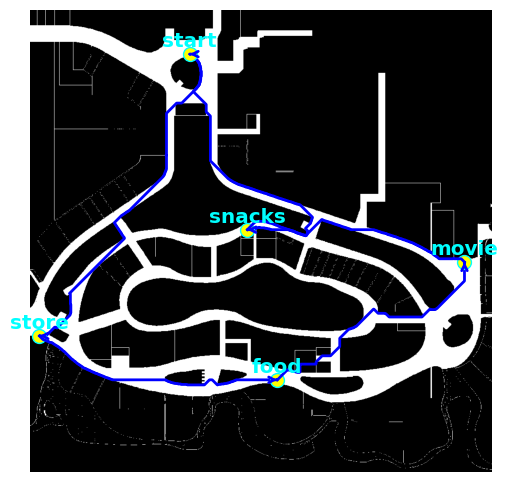

In [19]:
cost, path = tsp_floyd(graph5x5)

path_pairs = [ (path[i], path[i+1]) for i in range(len(path)-1)]
path_names = [loca_lst[id] for id in path]
path_output = "->".join(path_names)
print(f"Floyd,\npath:{path_output}, total distance:{cost}m")
plot_effect(grid_map_img, locations, path_pairs, loca_lst, path_dic, 100)

### Method2: Dijkstra

Dij,
path:start->store->food->movie->snacks->start, total distance:645.606m


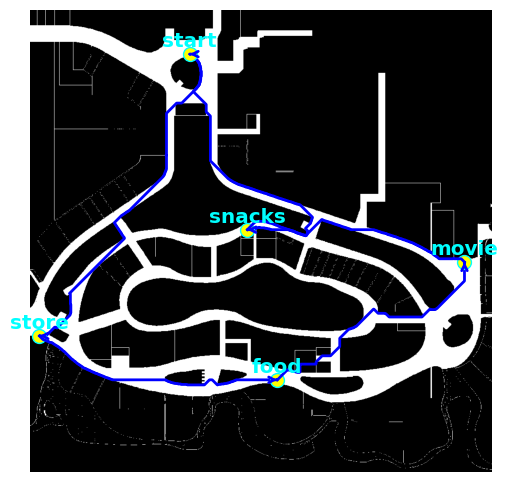

In [20]:
cost, path = tsp_dijkstra(graph5x5)

path_pairs = [ (path[i], path[i+1]) for i in range(len(path)-1)]
path_names = [loca_lst[id] for id in path]
path_output = "->".join(path_names)
print(f"Dij,\npath:{path_output}, total distance:{cost}m")
plot_effect(grid_map_img, locations, path_pairs, loca_lst, path_dic, 100)